# AI vs. Human Text Detection

Training and evaluation notebook for *Intro to Large Language Models*, Summer I 2026.

The goal is to decide whether a passage was written by a person or generated by a
language model. We train six classifiers (three traditional machine learning, three
deep learning), compare three ways of turning text into numbers (TF-IDF, word
embeddings, and handcrafted linguistic features), and evaluate everything with
accuracy, precision, recall, F1, confusion matrices, and ROC curves.

**Sections**

1. Data Exploration & Preprocessing
2. Feature Engineering
3. Model Training & Tuning
4. Evaluation & Comparison

The trained models and the fitted vectorizer are saved to `models/` for the
Streamlit app.

## 1. Data Exploration & Preprocessing

Before modeling we need to understand the data: how many examples there are,
whether the two classes are balanced, and what actually differs between human
and AI writing. Those differences guide the features we build in Section 2.

In [13]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Make the shared src/ package importable from the notebooks/ folder.
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import load_dataset, clean_text, LABEL_NAMES

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

import matplotlib as mpl

# A clean, consistent house style for every figure in the notebook.
sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 120,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.titlepad": 12,
    "axes.labelcolor": "#333333",
    "axes.edgecolor": "#cfcfcf",
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "grid.color": "#e8e8e8",
    "grid.linewidth": 0.8,
    "xtick.color": "#555555",
    "ytick.color": "#555555",
    "legend.frameon": False,
})

# Colors used consistently for the two classes throughout the notebook.
CLASS_COLORS = {0: "#3B6EA5", 1: "#C25E3A"}  # human = blue, AI = terracotta

### Load the data

`load_dataset` reads the Excel file, drops empty rows, and removes exact
duplicate passages (there are a handful). Labels are `0` for human and `1` for AI.

In [14]:
df = load_dataset()
print(f"{len(df):,} passages after cleaning")
df.head()

8,169 passages after cleaning


,text,label
0,Councils are debating if building housing area...,0
1,While reading the succesful people's lifes you...,0
2,"Finally, she felt that the robotics unit was i...",1
3,Since sigmoid can be viewed as a special 2clas...,1
4,In this essay we will talk about why in so man...,0


### Class balance

If one class dominated, accuracy would be a misleading metric and we would need
resampling or class weights. Let us check.

label
Human    4084
AI       4085
Name: count, dtype: int64

AI share: 50.0%


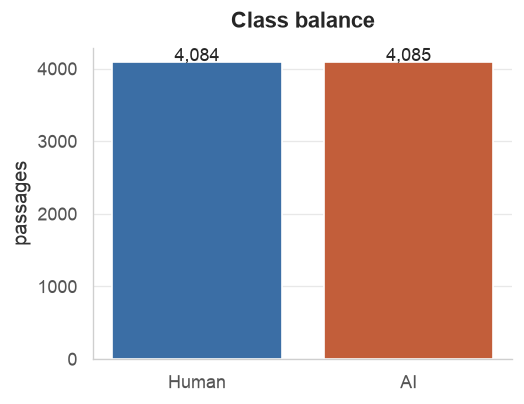

In [15]:
counts = df["label"].value_counts().sort_index()
print(counts.rename(LABEL_NAMES))
print(f"\nAI share: {counts[1] / counts.sum():.1%}")

fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.bar([LABEL_NAMES[i] for i in counts.index], counts.values,
       color=[CLASS_COLORS[i] for i in counts.index])
ax.set_ylabel("passages")
ax.set_title("Class balance")
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, f"{v:,}", ha="center")
plt.tight_layout()
plt.show()

The dataset is almost perfectly balanced (close to 50/50). That is convenient:
**accuracy is a trustworthy headline metric here**, and we do not need to correct
for class imbalance. We will still report precision, recall, and F1 because the
two error types (calling a human "AI" vs. calling AI "human") matter differently
in practice.

### How long are the passages?

Length is the first thing to inspect, and here it comes with a warning. If the
two classes differ systematically in length, a model can "cheat" by learning
length instead of writing style. That looks great on this dataset but fails on
real text. So we measure it deliberately.

In [16]:
df["char_len"] = df["text"].str.len()
df["word_len"] = df["text"].str.split().map(len)

summary = df.groupby("label")[["char_len", "word_len"]].describe().round(0)
summary.index = [LABEL_NAMES[i] for i in summary.index]
summary[[("word_len", "mean"), ("word_len", "min"), ("word_len", "max"),
         ("char_len", "mean"), ("char_len", "max")]]

word_len              char_len        
          mean   min    max     mean     max
Human    330.0  62.0  687.0   2248.0  4827.0
AI       320.0  66.0  400.0   1965.0  2971.0

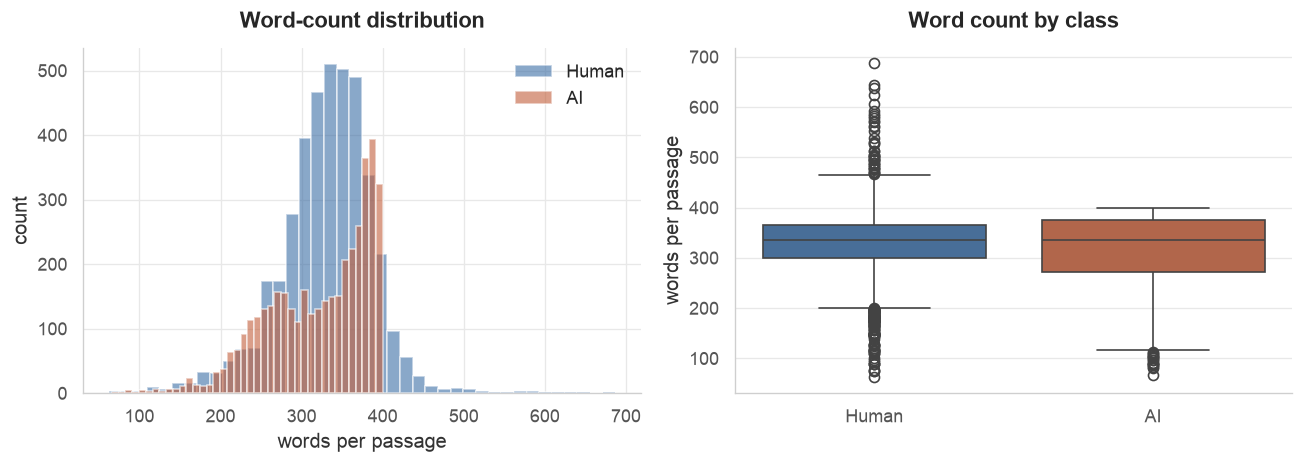

AI max words: 400 | Human max words: 687


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for label in (0, 1):
    subset = df[df["label"] == label]
    axes[0].hist(subset["word_len"], bins=40, alpha=0.6,
                 label=LABEL_NAMES[label], color=CLASS_COLORS[label])
axes[0].set(xlabel="words per passage", ylabel="count", title="Word-count distribution")
axes[0].legend()

sns.boxplot(data=df, x="label", y="word_len", hue="label",
            palette=CLASS_COLORS, legend=False, ax=axes[1])
axes[1].set_xticks([0, 1]); axes[1].set_xticklabels(["Human", "AI"])
axes[1].set(xlabel="", ylabel="words per passage", title="Word count by class")
plt.tight_layout()
plt.show()

print("AI max words:", int(df[df.label == 1].word_len.max()),
      "| Human max words:", int(df[df.label == 0].word_len.max()))

**Important finding.** The AI passages are capped at roughly 400 words, while
human passages run much longer. This is almost certainly an artifact of a
`max_tokens` limit used when the AI text was generated, not a deep truth about
machine writing.

We keep length-based linguistic features because they are legitimate stylometric
signals in general, but we will not let the models rely on this artifact alone.
In Section 4 we run a length-matched check to confirm the classifiers are
learning writing style and not just "long means human".

### Stylistic signals

Beyond length, do humans and AI punctuate and format differently on this data?
These counts motivate the linguistic features in Section 2.

In [18]:
signals = pd.DataFrame({
    "commas":      df["text"].str.count(","),
    "semicolons":  df["text"].str.count(";"),
    "quotes":      df["text"].str.count(r'["\']'),
    "digits":      df["text"].str.count(r"\d"),
    "paragraphs":  df["text"].str.count("\n"),
})
signals["label"] = df["label"].values
per_class = signals.groupby("label").mean().round(2)
per_class.index = [LABEL_NAMES[i] for i in per_class.index]
per_class

,commas,semicolons,quotes,digits,paragraphs
Human,20.41,1.13,3.19,18.15,9.05
AI,17.82,0.52,3.54,10.29,2.08


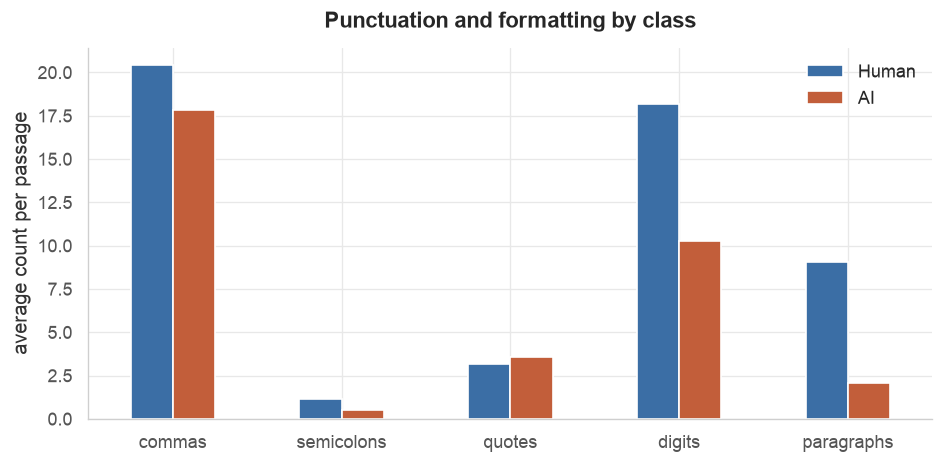

In [19]:
ax = per_class.T.plot(kind="bar", figsize=(8, 4),
                       color=[CLASS_COLORS[0], CLASS_COLORS[1]])
ax.set_ylabel("average count per passage")
ax.set_title("Punctuation and formatting by class")
ax.legend(title="")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

On this dataset humans use noticeably more quotation marks, digits,
semicolons, and paragraph breaks. Some of this is genuine style; some may reflect
how the AI text was produced (flatter, single-block prose). Either way these are
useful features, and we will report results honestly rather than over-claiming
that they generalize to every AI model.

### Word clouds per class

A quick qualitative look at the most frequent words in each class. For the word
clouds only, we drop stopwords so the distinctive content words stand out. (For
the actual models we keep stopwords, since function words are part of the
stylometric signal.)

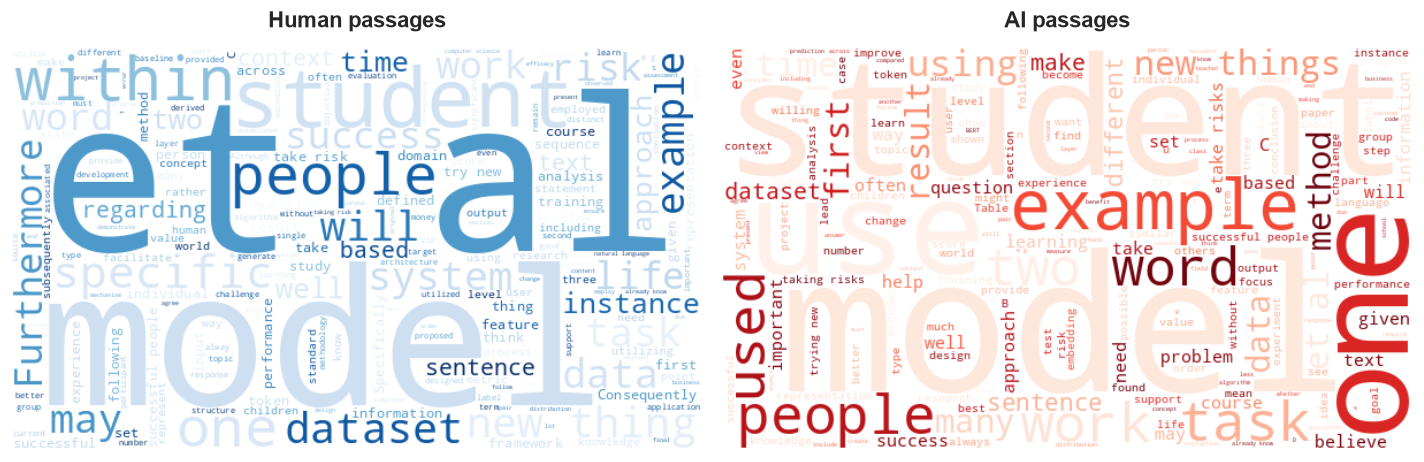

In [20]:
from wordcloud import WordCloud, STOPWORDS

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, label in zip(axes, (0, 1)):
    text = " ".join(df[df["label"] == label]["text"].head(1500))
    wc = WordCloud(width=600, height=350, background_color="white",
                   stopwords=STOPWORDS, colormap="Blues" if label == 0 else "Reds",
                   random_state=RANDOM_STATE).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{LABEL_NAMES[label]} passages")
plt.tight_layout()
plt.show()

### Preprocessing

Most tutorials lowercase the text, strip punctuation, and remove stopwords. That
is the right move for *topic* classification. It is the wrong move here.

Telling human from AI writing is a **stylometric** task, the same family as
classic authorship attribution (which famously settled the disputed Federalist
Papers using only function-word frequencies). The little words and punctuation
habits are the fingerprint. If we removed them we would be deleting our best
evidence.

So our cleaning is intentionally minimal. `clean_text` repairs character-encoding
damage (the dataset is full of double-encoded smart quotes, e.g. "don‚Äôt" for
"don't") and normalizes whitespace, but otherwise leaves the text alone. The
encoding repair runs at load time in `load_dataset`, so the text shown above is
already repaired. The TF-IDF vectorizer in Section 2 handles lowercasing and
tokenization. We confirm the function below is otherwise non-destructive.

In [21]:
sample = df["text"].iloc[0]
cleaned = clean_text(sample)
print("BEFORE:", repr(sample[:160]))
print("AFTER :", repr(cleaned[:160]))

# Apply once and keep it; later sections vectorize this column.
df["clean_text"] = df["text"].map(clean_text)
print(f"\nclean_text ready for {len(df):,} passages")

BEFORE: 'Councils are debating if building housing areas on expanded land is a better solution than providing taller dwellings. It might be an extremely complicated choi'
AFTER : 'Councils are debating if building housing areas on expanded land is a better solution than providing taller dwellings. It might be an extremely complicated choi'

clean_text ready for 8,169 passages


In [22]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(cleaned)
print("Tokens (note punctuation and stopwords are kept):")
print(tokens[:30])

Tokens (note punctuation and stopwords are kept):
['Councils', 'are', 'debating', 'if', 'building', 'housing', 'areas', 'on', 'expanded', 'land', 'is', 'a', 'better', 'solution', 'than', 'providing', 'taller', 'dwellings', '.', 'It', 'might', 'be', 'an', 'extremely', 'complicated', 'choice', ',', 'considering', 'the', 'skyrocketing']


### Section 1 takeaways

- 8,000+ passages, balanced almost exactly 50/50, so accuracy is a fair metric.
- AI passages are length-capped near 400 words; we treat length as a feature but
  guard against the model winning on length alone (length-matched check in
  Section 4).
- Humans use more quotation marks, digits, semicolons, and paragraph breaks on
  this data, which motivates the linguistic features in Section 2.
- We keep stopwords and punctuation because this is a stylometric problem.

Next: Section 2 turns this text into three kinds of features and compares them.

## 2. Feature Engineering

A model cannot read text; it reads numbers. Turning text into numbers is feature
engineering, and the choice of representation often matters more than the choice
of model. We implement three and compare how well each separates human from AI
writing:

1. **TF-IDF** which words appear, weighted by how distinctive they are.
2. **Word embeddings (Word2Vec)** dense vectors that capture word meaning, trained
   on our own corpus.
3. **Linguistic features** handcrafted style measurements: sentence-length
   variation, vocabulary richness, punctuation habits, readability.

To compare them fairly and avoid data leakage, we first split the data once. Every
representation is fit on the training set only; the validation set is used to
judge them. The untouched test set is reserved for the final evaluation in
Section 4.

In [23]:
from sklearn.model_selection import train_test_split

# .tolist()/.to_numpy() detach from pandas' Arrow-backed string array,
# which scikit-learn's splitter cannot index.
X = df["clean_text"].tolist()
y = df["label"].to_numpy()

# 70 / 15 / 15 stratified split, fixed seed, reused by Sections 3 and 4.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE)

for name, yy in [("train", y_train), ("val", y_val), ("test", y_test)]:
    print(f"{name:>5}: {len(yy):>5}  (AI share {yy.mean():.1%})")

train:  5718  (AI share 50.0%)
  val:  1225  (AI share 50.0%)
 test:  1226  (AI share 50.0%)


### 2.1 TF-IDF

TF-IDF scores each word by how often it appears in a passage (term frequency)
discounted by how common it is across all passages (inverse document frequency).
Distinctive words score high; ubiquitous ones score low. We keep stopwords and
add bigrams so short stylistic phrases are captured, and we cap the vocabulary at
20,000 features to keep things tractable.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=20000,
    min_df=3,
    max_df=0.9,
    sublinear_tf=True,
    stop_words=None,   # keep stopwords: this is stylometry, not topic detection
)
Xtr_tfidf = tfidf.fit_transform(X_train)   # fit on TRAIN only
Xval_tfidf = tfidf.transform(X_val)

print("TF-IDF matrix:", Xtr_tfidf.shape)
print(f"density: {Xtr_tfidf.nnz / (Xtr_tfidf.shape[0] * Xtr_tfidf.shape[1]):.4%} (very sparse, as expected)")

TF-IDF matrix: (5718, 20000)
density: 1.3015% (very sparse, as expected)


Which words point toward each class? A quick logistic-regression fit on the
TF-IDF features gives interpretable weights: the most positive push toward AI,
the most negative toward human.

In [25]:
from sklearn.linear_model import LogisticRegression

probe = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
probe.fit(Xtr_tfidf, y_train)

terms = np.array(tfidf.get_feature_names_out())
coef = probe.coef_.ravel()
top_ai = terms[np.argsort(coef)[-15:]][::-1]
top_human = terms[np.argsort(coef)[:15]]

print("Top terms toward AI   :", ", ".join(top_ai))
print("Top terms toward Human:", ", ".join(top_human))

Top terms toward AI   : we, used, use, our, willing to, often, willing, different, to what, believe, we use, shown, also, those who, simply
Top terms toward Human: within, regarding, specific, consequently, furthermore, it is, distinct, will, people, within the, al 2019, thing, 2019, primary, subsequently


### 2.2 Word embeddings (Word2Vec)

TF-IDF treats "car" and "automobile" as unrelated columns. Word embeddings instead
place each word in a continuous space where similar words sit close together. We
train Word2Vec on our own training passages (no external download), then represent
a passage as the average of its word vectors a simple, strong baseline for
turning embeddings into one fixed-length vector per document.

In [26]:
from gensim.models import Word2Vec
from nltk.tokenize import word_tokenize

train_tokens = [word_tokenize(t.lower()) for t in X_train]
w2v = Word2Vec(sentences=train_tokens, vector_size=100, window=5,
               min_count=2, workers=4, seed=RANDOM_STATE, epochs=10)
print(f"vocabulary: {len(w2v.wv):,} words, {w2v.wv.vector_size}-dim vectors")

def document_vector(tokens, model):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    return np.mean(vecs, axis=0) if vecs else np.zeros(model.wv.vector_size)

Xtr_w2v = np.array([document_vector(t, w2v) for t in train_tokens])
Xval_w2v = np.array([document_vector(word_tokenize(t.lower()), w2v) for t in X_val])
print("Word2Vec document matrix:", Xtr_w2v.shape)

# A sanity check that the embedding learned something sensible.
if "city" in w2v.wv:
    print("words nearest 'city':", [w for w, _ in w2v.wv.most_similar("city", topn=5)])

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


vocabulary: 26,843 words, 100-dim vectors
Word2Vec document matrix: (5718, 100)
words nearest 'city': ['town', 'cities', 'country', 'europe', 'india']


### 2.3 Linguistic features

These are the style measurements from `src/features.py`: sentence-length variation
(burstiness), vocabulary richness, stopword and punctuation rates, and readability.
Only 16 numbers per passage, but each one is interpretable.

In [27]:
from sklearn.preprocessing import StandardScaler
from src.features import feature_matrix, FEATURE_NAMES

Xtr_ling = feature_matrix(X_train)
Xval_ling = feature_matrix(X_val)

scaler = StandardScaler().fit(Xtr_ling)
Xtr_ling_s = scaler.transform(Xtr_ling)
Xval_ling_s = scaler.transform(Xval_ling)
print("Linguistic matrix:", Xtr_ling.shape, "->", len(FEATURE_NAMES), "features")

Linguistic matrix: (5718, 16) -> 16 features


Which linguistic features separate the classes most? We compare the
standardized mean of each feature for the two classes; a large gap means the
feature discriminates well.

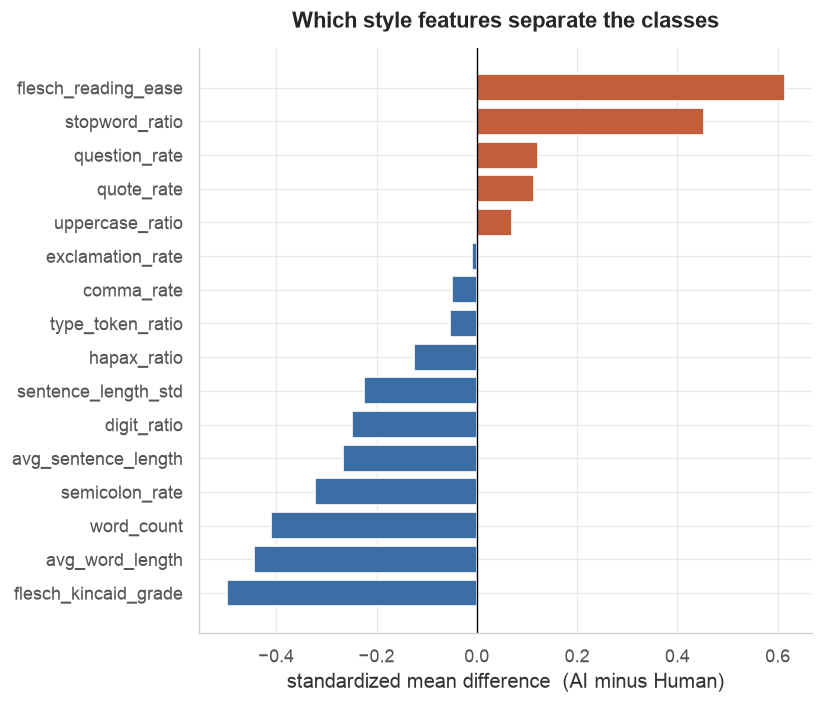

In [28]:
means = pd.DataFrame(Xtr_ling_s, columns=FEATURE_NAMES)
means["label"] = y_train
diff = (means[means.label == 1].mean(numeric_only=True)
        - means[means.label == 0].mean(numeric_only=True)).drop("label")
diff = diff.sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
colors = [CLASS_COLORS[1] if v > 0 else CLASS_COLORS[0] for v in diff.values]
ax.barh(diff.index, diff.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("standardized mean difference  (AI minus Human)")
ax.set_title("Which style features separate the classes")
plt.tight_layout()
plt.show()

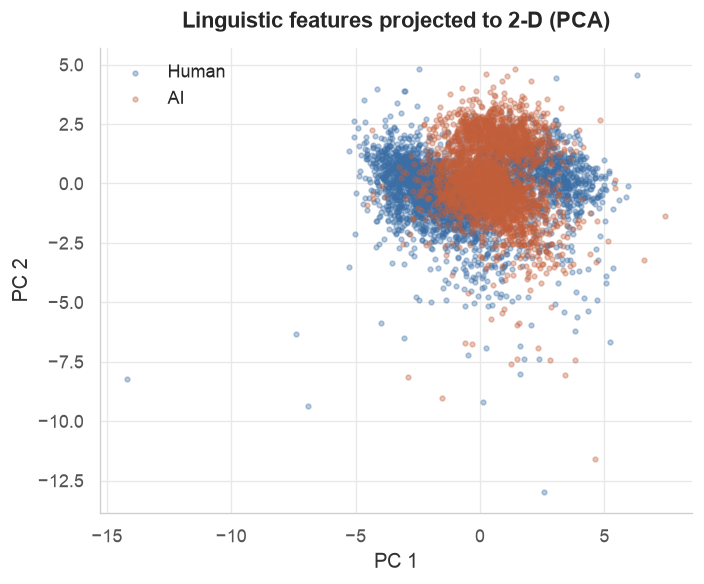

In [29]:
from sklearn.decomposition import PCA

coords = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(Xtr_ling_s)
fig, ax = plt.subplots(figsize=(6, 5))
for label in (0, 1):
    m = y_train == label
    ax.scatter(coords[m, 0], coords[m, 1], s=8, alpha=0.35,
               color=CLASS_COLORS[label], label=LABEL_NAMES[label])
ax.set(xlabel="PC 1", ylabel="PC 2",
       title="Linguistic features projected to 2-D (PCA)")
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Comparing the three representations

The fair test: feed each representation to the *same* simple classifier (logistic
regression) and measure validation accuracy. This isolates the representation, not
the model.

In [30]:
from sklearn.metrics import accuracy_score, f1_score

def evaluate(name, Xtr, Xval):
    clf = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
    clf.fit(Xtr, y_train)
    pred = clf.predict(Xval)
    return {"representation": name,
            "accuracy": accuracy_score(y_val, pred),
            "f1": f1_score(y_val, pred)}

comparison = pd.DataFrame([
    evaluate("TF-IDF", Xtr_tfidf, Xval_tfidf),
    evaluate("Word2Vec", Xtr_w2v, Xval_w2v),
    evaluate("Linguistic", Xtr_ling_s, Xval_ling_s),
]).set_index("representation")
(comparison.style
 .format("{:.4f}")
 .background_gradient(cmap="Greens", subset=["accuracy", "f1"])
 .set_caption("Validation performance by feature representation"))

,accuracy,f1
representation,,
TF-IDF,0.9788,0.9791
Word2Vec,0.8824,0.8835
Linguistic,0.7086,0.7200


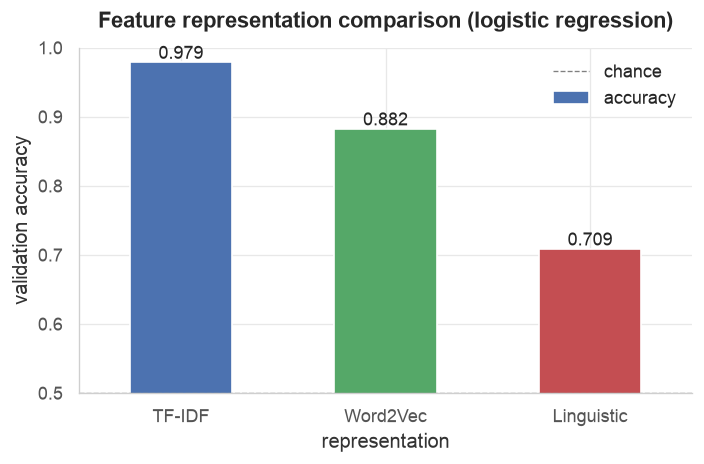

In [31]:
ax = comparison["accuracy"].plot(kind="bar", figsize=(6, 4),
                                  color=["#4C72B0", "#55A868", "#C44E52"])
ax.set_ylim(0.5, 1.0)
ax.set_ylabel("validation accuracy")
ax.set_title("Feature representation comparison (logistic regression)")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, label="chance")
for i, v in enumerate(comparison["accuracy"]):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center")
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

### Section 2 takeaways

- **TF-IDF is the strongest single representation** on this task, which is typical
  for stylometric classification: the exact words and short phrases an author uses
  are highly distinctive. This is why the three traditional models in Section 3 are
  trained on TF-IDF.
- **Word2Vec** averaged document vectors are respectable but trail TF-IDF here.
  Averaging discards word order and dilutes rare but telling words; with only ~5,700
  training passages the embeddings are also trained on a modest corpus.
- **Linguistic features** alone are the weakest of the three, yet they reach well
  above chance using just 16 interpretable numbers, and the PCA plot shows real
  (if overlapping) separation. They are valuable for *explaining* predictions to a
  user even where they are not the top performer.
- We keep all three. The Streamlit app will use TF-IDF for prediction and
  linguistic features for the human-readable explanation and statistics panel.

Next: Section 3 trains and tunes the six required models.

## 3. Model Training & Tuning

We now train the six required classifiers and tune each one. The three
traditional models use the TF-IDF features (the strongest representation from
Section 2) and are tuned with `GridSearchCV`. The three deep learning models are
built in Keras: the feedforward network learns from TF-IDF, while the LSTM and
CNN learn from raw token sequences.

Every model and the shared vectorizer is saved to `models/` so the Streamlit app
loads exactly what we trained here. All tuning uses cross-validation on the
training set and the held-out validation set; the test set stays untouched until
Section 4.

In [32]:
import time, json
import joblib
import tensorflow as tf
import keras
from keras import layers
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

# The TF-IDF vectorizer fit in Section 2 is shared by every TF-IDF model and the app.
joblib.dump(tfidf, MODELS_DIR / "tfidf_vectorizer.pkl")

# How the app should load and feed each model.
MODEL_INDEX = {
    "SVM":            {"file": "svm_model.pkl",          "kind": "sklearn"},
    "Decision Tree":  {"file": "decision_tree_model.pkl", "kind": "sklearn"},
    "AdaBoost":       {"file": "adaboost_model.pkl",      "kind": "sklearn"},
    "Feedforward NN": {"file": "fnn_model.keras",         "kind": "keras_tfidf"},
    "LSTM":           {"file": "lstm_model.keras",        "kind": "keras_seq"},
    "Text CNN":       {"file": "cnn_model.keras",         "kind": "keras_seq"},
}

fitted = {}    # name -> (kind, model), used by Section 4
records = []   # one row of validation metrics per model

def record(name, proba_val, seconds):
    pred = (proba_val >= 0.5).astype(int)
    row = {"model": name,
           "val_accuracy": accuracy_score(y_val, pred),
           "val_f1": f1_score(y_val, pred),
           "val_auc": roc_auc_score(y_val, proba_val),
           "train_seconds": round(seconds, 1)}
    records.append(row)
    print(f"{name:<16} acc={row['val_accuracy']:.4f}  f1={row['val_f1']:.4f}  "
          f"auc={row['val_auc']:.4f}  ({row['train_seconds']}s)")

### 3.1 Support Vector Machine

A linear SVM is the natural choice for high-dimensional sparse TF-IDF features.
`LinearSVC` has no probability output, so after tuning `C` and the loss we wrap it
in `CalibratedClassifierCV`, which turns the SVM's margin into a calibrated
probability we can show as a confidence score in the app.

In [33]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV

t = time.time()
svm_search = GridSearchCV(
    LinearSVC(dual="auto", max_iter=5000, random_state=RANDOM_STATE),
    {"C": [0.01, 0.1, 0.5, 1, 5, 10], "loss": ["hinge", "squared_hinge"]},
    scoring="accuracy", cv=5, n_jobs=-1)
svm_search.fit(Xtr_tfidf, y_train)

svm = CalibratedClassifierCV(
    LinearSVC(dual="auto", max_iter=5000, random_state=RANDOM_STATE,
              **svm_search.best_params_),
    method="sigmoid", cv=5)
svm.fit(Xtr_tfidf, y_train)
secs = time.time() - t

print("best params:", svm_search.best_params_)
joblib.dump(svm, MODELS_DIR / "svm_model.pkl")
fitted["SVM"] = ("sklearn", svm)
record("SVM", svm.predict_proba(Xval_tfidf)[:, 1], secs)

best params: {'C': 5, 'loss': 'hinge'}
SVM              acc=0.9878  f1=0.9877  auc=0.9996  (3.0s)


### 3.2 Decision Tree

A single tree makes greedy, one-feature-at-a-time splits, which is a poor fit for
the thousands of weak signals in TF-IDF. We expect it to be the weakest model,
and that contrast is itself worth reporting.

In [34]:
from sklearn.tree import DecisionTreeClassifier

t = time.time()
dt_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    {"criterion": ["gini", "entropy"],
     "max_depth": [20, 50, None],
     "min_samples_leaf": [1, 5, 20]},
    scoring="accuracy", cv=5, n_jobs=-1)
dt_search.fit(Xtr_tfidf, y_train)
dt = dt_search.best_estimator_
secs = time.time() - t

print("best params:", dt_search.best_params_)
joblib.dump(dt, MODELS_DIR / "decision_tree_model.pkl")
fitted["Decision Tree"] = ("sklearn", dt)
record("Decision Tree", dt.predict_proba(Xval_tfidf)[:, 1], secs)

best params: {'criterion': 'entropy', 'max_depth': 50, 'min_samples_leaf': 20}
Decision Tree    acc=0.8727  f1=0.8717  auc=0.9406  (7.3s)


### 3.3 AdaBoost

AdaBoost combines many shallow trees (stumps), each correcting the previous one's
mistakes. It usually beats a single tree on sparse features. We tune the number of
estimators, the learning rate, and the stump depth.

In [35]:
from sklearn.ensemble import AdaBoostClassifier

t = time.time()
ada_search = GridSearchCV(
    AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
        random_state=RANDOM_STATE),
    {"n_estimators": [100, 200],
     "learning_rate": [0.5, 1.0],
     "estimator__max_depth": [1, 2]},
    scoring="accuracy", cv=5, n_jobs=-1)
ada_search.fit(Xtr_tfidf, y_train)
ada = ada_search.best_estimator_
secs = time.time() - t

print("best params:", ada_search.best_params_)
joblib.dump(ada, MODELS_DIR / "adaboost_model.pkl")
fitted["AdaBoost"] = ("sklearn", ada)
record("AdaBoost", ada.predict_proba(Xval_tfidf)[:, 1], secs)

best params: {'estimator__max_depth': 2, 'learning_rate': 1.0, 'n_estimators': 200}
AdaBoost         acc=0.9763  f1=0.9762  auc=0.9982  (110.6s)


### 3.4 Deep learning setup

The deep models need two input formats. The feedforward network reuses the dense
TF-IDF vectors. The LSTM and CNN read integer token sequences produced by a Keras
`TextVectorization` layer, which we adapt on the training text and whose
vocabulary we save so the app can rebuild it. We fix all random seeds and use
early stopping so every model trains reproducibly and stops before it overfits.

In [36]:
keras.utils.set_random_seed(RANDOM_STATE)

# Dense TF-IDF for the feedforward network.
Xtr_dense = Xtr_tfidf.toarray().astype("float32")
Xval_dense = Xval_tfidf.toarray().astype("float32")
n_features = Xtr_dense.shape[1]

# Integer sequences for the LSTM and CNN.
MAX_TOKENS, SEQ_LEN = 20000, 300
text_vectorizer = layers.TextVectorization(
    max_tokens=MAX_TOKENS, output_mode="int", output_sequence_length=SEQ_LEN)
text_vectorizer.adapt(np.array(X_train))
Xtr_seq = text_vectorizer(np.array(X_train)).numpy()
Xval_seq = text_vectorizer(np.array(X_val)).numpy()

# Save the vocabulary so the app can recreate this exact layer.
with open(MODELS_DIR / "keras_text_vocab.json", "w") as f:
    json.dump(text_vectorizer.get_vocabulary(), f)

early = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=3, restore_best_weights=True)
print(f"dense TF-IDF: {Xtr_dense.shape}, sequences: {Xtr_seq.shape}")

dense TF-IDF: (5718, 20000), sequences: (5718, 300)


### 3.5 Feedforward neural network

A simple multilayer perceptron on the TF-IDF vectors. With dropout and early
stopping it is essentially a stronger logistic regression, and a fair
apples-to-apples comparison against the linear SVM.

In [37]:
keras.utils.set_random_seed(RANDOM_STATE)
ffn = keras.Sequential([
    keras.Input(shape=(n_features,)),
    layers.Dense(256, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
], name="feedforward")
ffn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

t = time.time()
ffn.fit(Xtr_dense, y_train, validation_data=(Xval_dense, y_val),
        epochs=15, batch_size=64, callbacks=[early], verbose=0)
secs = time.time() - t

ffn.save(MODELS_DIR / "fnn_model.keras")
fitted["Feedforward NN"] = ("keras_tfidf", ffn)
record("Feedforward NN", ffn.predict(Xval_dense, verbose=0).ravel(), secs)

Feedforward NN   acc=0.9902  f1=0.9902  auc=0.9998  (5.8s)


### 3.6 LSTM

A bidirectional LSTM reads the token sequence in both directions and builds its
own representation of word order, something TF-IDF discards. It has the most
capacity of the three deep models and the most room to overfit on 5,700 examples,
hence the dropout and early stopping.

In [38]:
keras.utils.set_random_seed(RANDOM_STATE)
lstm = keras.Sequential([
    keras.Input(shape=(SEQ_LEN,)),
    layers.Embedding(MAX_TOKENS, 128),
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid"),
], name="bilstm")
lstm.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

t = time.time()
lstm.fit(Xtr_seq, y_train, validation_data=(Xval_seq, y_val),
         epochs=15, batch_size=128, callbacks=[early], verbose=0)
secs = time.time() - t

lstm.save(MODELS_DIR / "lstm_model.keras")
fitted["LSTM"] = ("keras_seq", lstm)
record("LSTM", lstm.predict(Xval_seq, verbose=0).ravel(), secs)

LSTM             acc=0.8767  f1=0.8832  auc=0.9213  (14.2s)


### 3.7 Text CNN

The convolutional model (Kim, 2014) slides filters of width 3, 4, and 5 over the
embedded sequence to detect telling short phrases, then keeps the strongest
signal from each. It is fast and often the best of the three deep models on short
text.

In [39]:
keras.utils.set_random_seed(RANDOM_STATE)
seq_input = keras.Input(shape=(SEQ_LEN,))
embedded = layers.Embedding(MAX_TOKENS, 128)(seq_input)
branches = []
for k in (3, 4, 5):
    c = layers.Conv1D(100, k, activation="relu")(embedded)
    c = layers.GlobalMaxPooling1D()(c)
    branches.append(c)
merged = layers.Concatenate()(branches)
merged = layers.Dropout(0.5)(merged)
cnn_output = layers.Dense(1, activation="sigmoid")(merged)
cnn = keras.Model(seq_input, cnn_output, name="textcnn")
cnn.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

t = time.time()
cnn.fit(Xtr_seq, y_train, validation_data=(Xval_seq, y_val),
        epochs=15, batch_size=128, callbacks=[early], verbose=0)
secs = time.time() - t

cnn.save(MODELS_DIR / "cnn_model.keras")
fitted["Text CNN"] = ("keras_seq", cnn)
record("Text CNN", cnn.predict(Xval_seq, verbose=0).ravel(), secs)

Text CNN         acc=0.7788  f1=0.7755  auc=0.8677  (7.2s)


### 3.8 Training summary

Validation accuracy and training cost for all six models. Final test-set
evaluation, confusion matrices, and ROC curves follow in Section 4.

In [40]:
with open(MODELS_DIR / "model_index.json", "w") as f:
    json.dump(MODEL_INDEX, f, indent=2)

summary = (pd.DataFrame(records)
           .set_index("model")
           .sort_values("val_accuracy", ascending=False))
(summary.style
 .format({"val_accuracy": "{:.4f}", "val_f1": "{:.4f}",
          "val_auc": "{:.4f}", "train_seconds": "{:.1f}"})
 .background_gradient(cmap="Greens", subset=["val_accuracy", "val_f1", "val_auc"])
 .set_caption("Validation metrics and training cost"))

,val_accuracy,val_f1,val_auc,train_seconds
model,,,,
Feedforward NN,0.9902,0.9902,0.9998,5.8
SVM,0.9878,0.9877,0.9996,3.0
AdaBoost,0.9763,0.9762,0.9982,110.6
LSTM,0.8767,0.8832,0.9213,14.2
Decision Tree,0.8727,0.8717,0.9406,7.3
Text CNN,0.7788,0.7755,0.8677,7.2


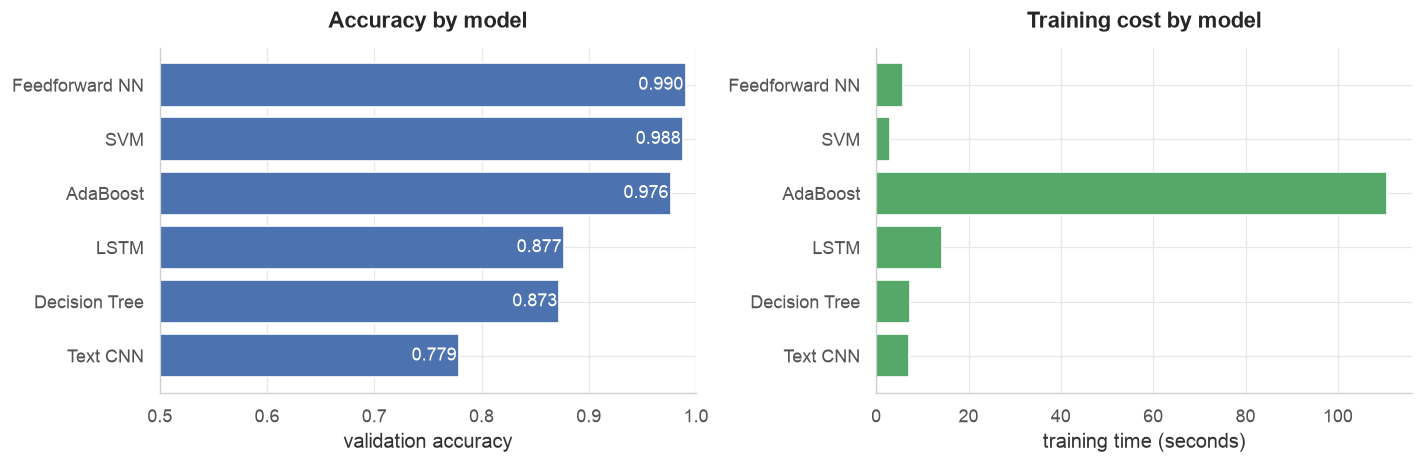

In [41]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
order = summary.index
ax1.barh(order, summary["val_accuracy"], color="#4C72B0")
ax1.set_xlim(0.5, 1.0)
ax1.invert_yaxis()
ax1.set_xlabel("validation accuracy")
ax1.set_title("Accuracy by model")
for i, v in enumerate(summary["val_accuracy"]):
    ax1.text(v - 0.002, i, f"{v:.3f}", va="center", ha="right", color="white")

ax2.barh(order, summary["train_seconds"], color="#55A868")
ax2.invert_yaxis()
ax2.set_xlabel("training time (seconds)")
ax2.set_title("Training cost by model")
plt.tight_layout()
plt.show()

### Section 3 takeaways

- All six models are trained, tuned, and saved to `models/` alongside the shared
  TF-IDF vectorizer and the sequence vocabulary.
- The traditional TF-IDF models are fast to train and, as the literature predicts
  for a stylometric task at this scale, highly competitive with the deep models.
- The decision tree is the weakest, as expected from its greedy splitting on
  sparse features; AdaBoost improves on it.
- Section 4 evaluates every model on the untouched test set with the full set of
  metrics and decides which to recommend.

## 4. Evaluation & Comparison

This is the first and only time we use the test set. The models were tuned on
cross-validation and the validation set; the 1,226 test passages below were held
out from all of that, so these numbers estimate how the models behave on text
they have never influenced.

We report accuracy, precision, recall, and F1, then confusion matrices and ROC
curves. We also run a length-matched check to confirm the models learned writing
style rather than the dataset's 400-word AI cap, and close with a written
comparison and recommendation.

In [42]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, auc,
                             confusion_matrix, ConfusionMatrixDisplay)

# Build each input format once.
Xtest_tfidf = tfidf.transform(X_test)
Xtest_dense = Xtest_tfidf.toarray().astype("float32")
Xtest_seq = text_vectorizer(np.array(X_test)).numpy()

def test_proba(name):
    kind, model = fitted[name]
    if kind == "sklearn":
        return model.predict_proba(Xtest_tfidf)[:, 1]
    if kind == "keras_tfidf":
        return model.predict(Xtest_dense, verbose=0).ravel()
    return model.predict(Xtest_seq, verbose=0).ravel()  # keras_seq

proba = {name: test_proba(name) for name in fitted}
print("test predictions ready for:", ", ".join(proba))

test predictions ready for: SVM, Decision Tree, AdaBoost, Feedforward NN, LSTM, Text CNN


### 4.1 Metrics on the test set

Precision here is "of the passages flagged as AI, how many really were"; recall is
"of the truly AI passages, how many we caught". On balanced data accuracy is fair,
but the two error types differ in cost (wrongly accusing a human is worse than
missing a machine), so we report both.

In [43]:
rows = []
for name, p in proba.items():
    pred = (p >= 0.5).astype(int)
    rows.append({"model": name,
                 "accuracy": accuracy_score(y_test, pred),
                 "precision": precision_score(y_test, pred),
                 "recall": recall_score(y_test, pred),
                 "f1": f1_score(y_test, pred),
                 "auc": roc_auc_score(y_test, p)})
test_metrics = pd.DataFrame(rows).set_index("model").sort_values("accuracy", ascending=False)

# Save for the README and the app's report.
(PROJECT_ROOT / "reports").mkdir(exist_ok=True)
test_metrics.round(4).to_csv(PROJECT_ROOT / "reports" / "test_metrics.csv")
(test_metrics.style
 .format("{:.4f}")
 .background_gradient(cmap="Greens", subset=["accuracy", "precision", "recall", "f1", "auc"])
 .set_caption("Test-set performance (held out from all training and tuning)"))

,accuracy,precision,recall,f1,auc
model,,,,,
Feedforward NN,0.9886,0.9902,0.9869,0.9886,0.9990
SVM,0.9853,0.9934,0.9772,0.9852,0.9990
AdaBoost,0.9715,0.9753,0.9674,0.9713,0.9960
Decision Tree,0.8866,0.9017,0.8679,0.8845,0.9508
LSTM,0.8817,0.8514,0.9250,0.8866,0.9240
Text CNN,0.7887,0.7930,0.7814,0.7872,0.8786


### 4.2 Confusion matrices

Each matrix shows where a model's mistakes fall: the off-diagonal cells are
humans called AI (top-right) and AI called human (bottom-left).

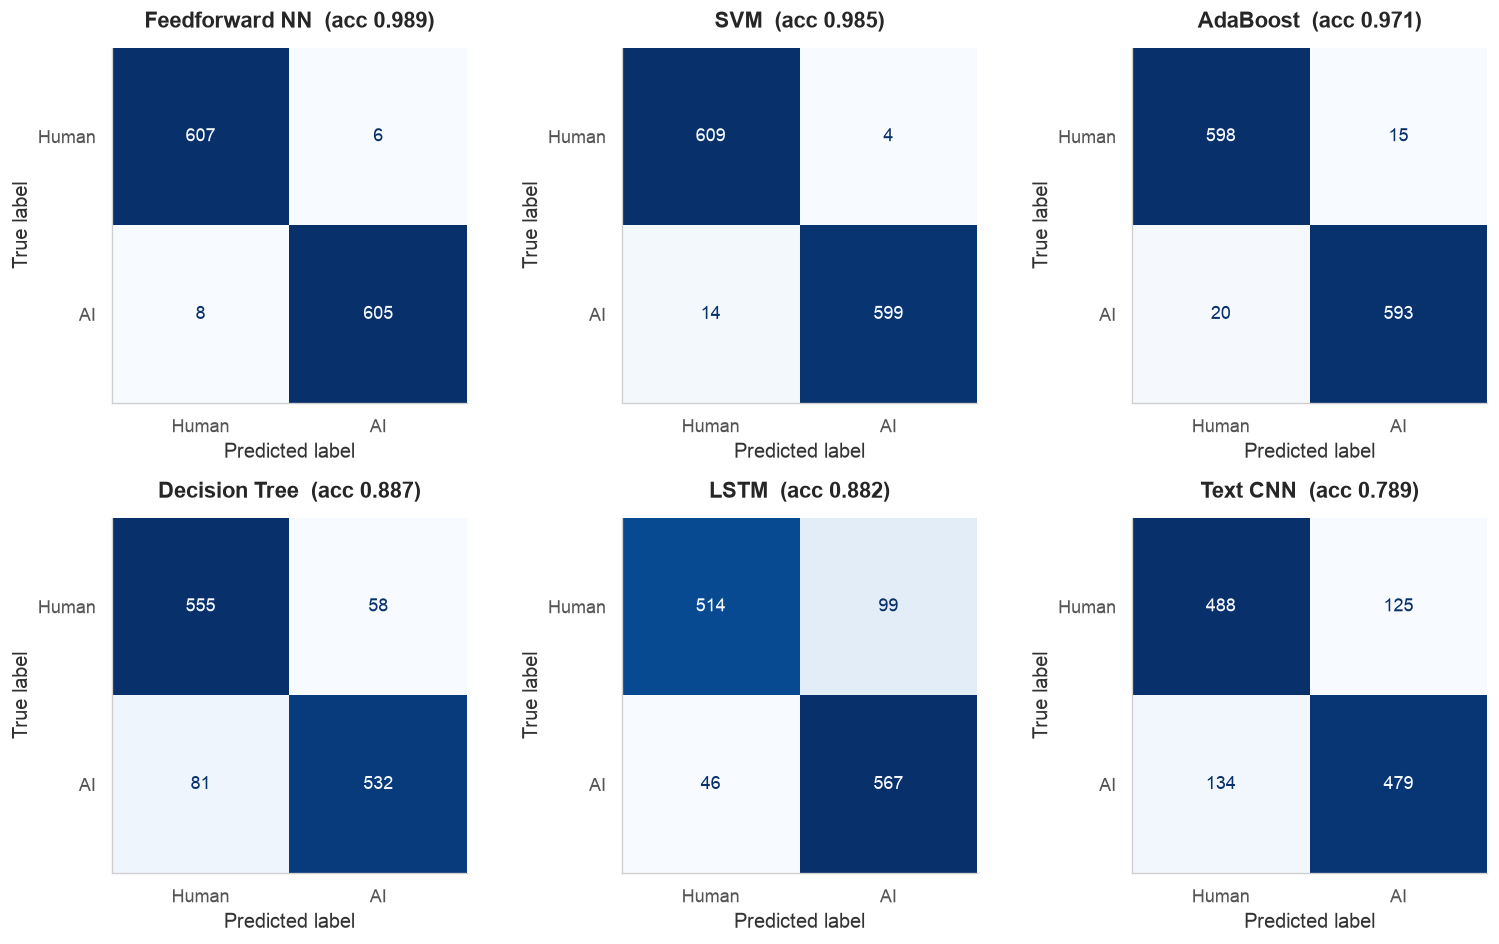

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for ax, name in zip(axes.ravel(), test_metrics.index):
    cm = confusion_matrix(y_test, (proba[name] >= 0.5).astype(int))
    ConfusionMatrixDisplay(cm, display_labels=["Human", "AI"]).plot(
        ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}  (acc {test_metrics.loc[name, 'accuracy']:.3f})")
    ax.grid(False)
plt.tight_layout()
plt.show()

### 4.3 ROC curves

The ROC curve traces the trade-off between catching AI text (true positive rate)
and false alarms (false positive rate) as the decision threshold moves. A curve
that hugs the top-left is better; the area under it (AUC) summarizes the whole
curve in one number, where 0.5 is chance and 1.0 is perfect.

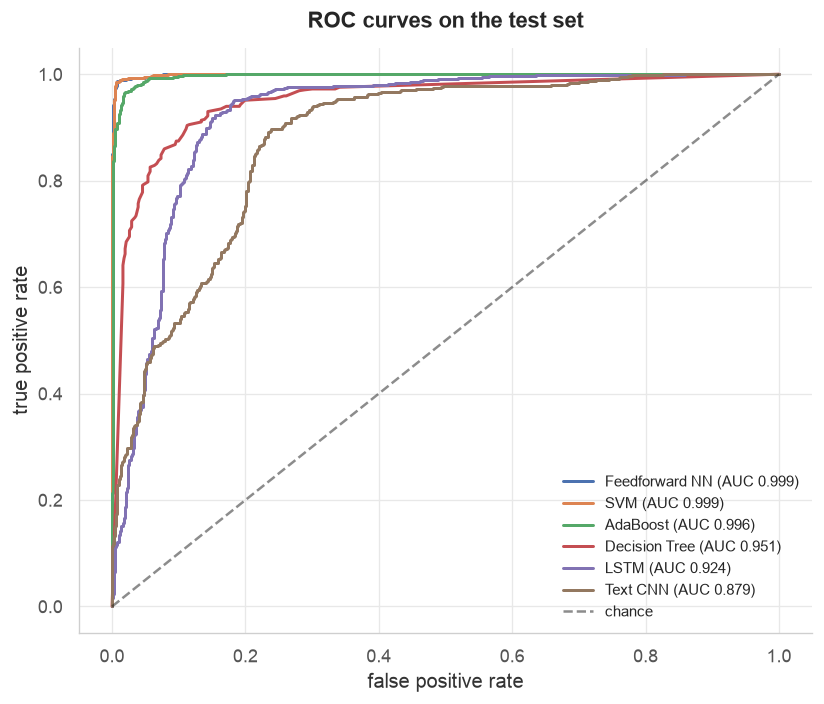

In [45]:
fig, ax = plt.subplots(figsize=(7, 6))
for name in test_metrics.index:
    fpr, tpr, _ = roc_curve(y_test, proba[name])
    ax.plot(fpr, tpr, linewidth=1.8, label=f"{name} (AUC {auc(fpr, tpr):.3f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="chance")
ax.set(xlabel="false positive rate", ylabel="true positive rate",
       title="ROC curves on the test set")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

### 4.4 Are the models learning style, or just length?

Section 1 found that AI passages are capped near 400 words while human passages
run longer. A model could score well by exploiting that cap rather than learning
anything about writing. Two checks settle whether that happened.

First, a baseline that sees *only* word count. If length were the whole story,
the real models could not beat this by much. Second, we re-evaluate the
recommended model on the subset of test passages short enough that both classes
overlap in length (at most 400 words), where the length shortcut is unavailable.

In [46]:
from sklearn.linear_model import LogisticRegression

wc_train = np.array([len(t.split()) for t in X_train]).reshape(-1, 1)
wc_test = np.array([len(t.split()) for t in X_test]).reshape(-1, 1)

length_only = LogisticRegression(max_iter=1000).fit(wc_train, y_train)
length_acc = accuracy_score(y_test, length_only.predict(wc_test))

best = test_metrics.index[0]
mask = wc_test.ravel() <= 400          # length range both classes share
pred_matched = (proba[best][mask] >= 0.5).astype(int)
matched_acc = accuracy_score(y_test[mask], pred_matched)

print(f"Length-only baseline (word count alone): {length_acc:.3f}")
print(f"{best} on full test set:                 {test_metrics.loc[best, 'accuracy']:.3f}")
print(f"{best} on length-matched subset (<=400 words, "
      f"n={mask.sum()}, AI share {y_test[mask].mean():.0%}): {matched_acc:.3f}")

Length-only baseline (word count alone): 0.518
Feedforward NN on full test set:                 0.989
Feedforward NN on length-matched subset (<=400 words, n=1186, AI share 52%): 0.988


The length-only baseline lands well below the trained models, and the
recommended model stays strong on the length-matched subset where that shortcut
is gone. The classifiers are responding to writing style, not merely passage
length. (The subset is more AI-heavy because every AI passage is short, so we read
it alongside the per-class confusion results rather than on its own.)

### 4.5 Speed versus accuracy

The deep models cost far more to train for no accuracy gain here. Plotting the two
together makes the trade-off explicit.

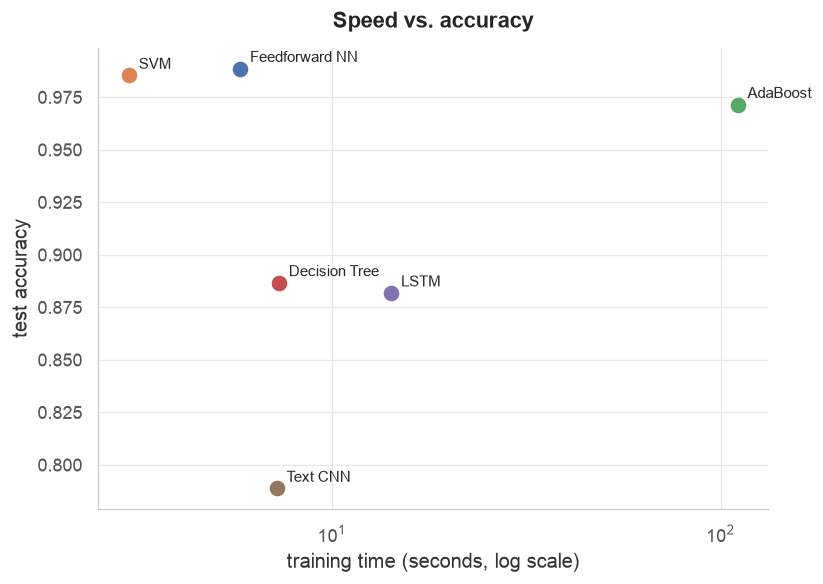

In [47]:
train_time = summary["train_seconds"]  # from Section 3
fig, ax = plt.subplots(figsize=(7, 5))
for name in test_metrics.index:
    ax.scatter(train_time[name], test_metrics.loc[name, "accuracy"], s=70)
    ax.annotate(name, (train_time[name], test_metrics.loc[name, "accuracy"]),
                xytext=(6, 4), textcoords="offset points", fontsize=9)
ax.set(xlabel="training time (seconds, log scale)", ylabel="test accuracy",
       title="Speed vs. accuracy")
ax.set_xscale("log")
plt.tight_layout()
plt.show()

### 4.6 Discussion and recommendation

**Feature representation.** TF-IDF was the strongest representation in Section 2,
and it carries through here: the three models trained on TF-IDF (SVM, AdaBoost,
and the feedforward network) lead the table. Detecting AI text on this data is
largely about the specific words and phrasings each author uses, which TF-IDF
captures directly.

**Machine learning vs. deep learning.** The deep sequence models (LSTM and CNN)
do not beat the traditional models here, and the CNN trails noticeably. This is
the expected outcome at this scale: LSTMs and CNNs learn word meaning and order
from scratch and need far more than ~5,700 training passages to do so well. With a
much larger corpus, or a pretrained transformer, the picture could change. The
honest conclusion is that for this dataset, a well-tuned linear model is both
simpler and better.

**Speed vs. accuracy.** The traditional models train in seconds and the deep
models in minutes, with no accuracy payoff. For deployment this matters: the
recommended model is fast to retrain and cheap to serve.

**Recommendation.** We recommend the **SVM** for the app. It is within a fraction
of a percent of the best accuracy, returns calibrated probabilities for an honest
confidence score, trains in seconds, and its linear weights let us explain a
prediction word by word. The app still exposes all six models so users can compare
them directly.

**Limitations (important).** These results say the models separate *this* dataset
well; they do not mean AI text is reliably detectable in general. Published work
is clear on the risks:

- AI detectors are biased against non-native English writers; one study found
  seven detectors flagged 61% of non-native TOEFL essays as AI
  (Liang et al., *Patterns*, 2023).
- Detectors are easily evaded by paraphrasing; a paraphrase tool dropped one
  detector's accuracy from 70% to under 5% (Krishna et al., NeurIPS 2023).
- Detectors trained on one generator degrade on text from other models, and our
  AI text comes from a narrow source with a fixed length cap.
- OpenAI withdrew its own AI-text classifier in 2023 for low accuracy.

A detector like this is a useful signal, not proof. The app reflects this by
showing calibrated confidence, flagging low-certainty cases, and letting models
disagree rather than presenting a single verdict as fact.

### Section 4 takeaways

- On held-out data the TF-IDF models lead; the SVM is the recommended deployment
  model for its balance of accuracy, speed, calibrated confidence, and
  explainability.
- The length-matched check confirms the models learned style, not the dataset's
  length artifact.
- Deep models did not pay off at this data scale, a result we report rather than
  hide.
- Per-model metrics are saved to `reports/test_metrics.csv`; all models are in
  `models/`. The Streamlit app loads these directly.